# Ray-casting schematic

Schematic of the polity-assignment pipeline: candidate polygons → ray-casting
→ smallest matching polygon. Panel 1 shows the parity test (an odd number of
edge crossings means the point is inside). Panel 2 shows the tie-break: when
several polygons enclose the point, the one with the smallest bounding-box
area is chosen.

In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
from pathlib import Path

OUT = Path('fig_ray_casting.pdf')

# Geometry
EMPIRE = [
    (-0.4, 0.4), (3.0, -0.3), (6.6, -0.1), (9.6, 0.9),
    (10.6, 3.6), (9.8, 5.9), (6.8, 6.9), (3.0, 6.7),
    (0.4, 5.7), (-0.6, 3.0),
]
KINGDOM = [
    (1.4, 1.4), (4.6, 0.8), (7.2, 1.5), (7.8, 3.8),
    (6.6, 5.4), (3.4, 5.6), (1.6, 4.6), (1.0, 2.6),
]
NEIGHBOR = [
    (11.4, 1.6), (13.8, 1.4), (14.8, 2.8), (14.0, 4.6),
    (11.8, 4.8), (11.2, 3.4),
]
CITY = (3.8, 3.0)
RAY_X_MAX = 15.2

# Palette
NAVY = '#1f3a5f'
TEAL = '#0f766e'
ORANGE = '#d97706'
GREY = '#6b7280'
LIGHT_GREY = '#f3f4f6'
LIGHT_BLUE = '#dbe4ee'
LIGHT_TEAL = '#cce7e2'
RED = '#b91c1c'

## 1. Drawing helpers and the ray-casting primitive

`edge_crossings` walks the polygon edges and returns every point where a
horizontal ray from the test point intersects an edge to its right.
An odd count → point is inside the polygon.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon


def edge_crossings(point, polygon, x_max):
    px, py = point
    crossings = []
    n = len(polygon)
    for i in range(n):
        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % n]
        if (y1 > py) == (y2 > py):
            continue
        x_int = x1 + (py - y1) * (x2 - x1) / (y2 - y1)
        if px < x_int <= x_max:
            crossings.append((x_int, py))
    return sorted(crossings)


def draw_polygon(ax, coords, face, edge, label, label_pos, label_color, lw=1.6, ls='-'):
    ax.add_patch(Polygon(coords, closed=True, facecolor=face,
                         edgecolor=edge, linewidth=lw, linestyle=ls))
    ax.text(*label_pos, label, fontsize=9.5, color=label_color,
            fontweight='bold', ha='center')


def draw_ray(ax, start, end, color=GREY):
    arrow = FancyArrowPatch(start, end, arrowstyle='->',
                            mutation_scale=12, color=color,
                            linewidth=1.2, linestyle=(0, (4, 2)))
    ax.add_patch(arrow)


def draw_city(ax, point, color=NAVY, label='specific location'):
    ax.plot(*point, 'o', color=color, markersize=10,
            markeredgecolor='white', markeredgewidth=1.4, zorder=5)
    ax.annotate(label, point, xytext=(-32, -18), textcoords='offset points',
                fontsize=9.5, color=color, fontweight='bold')


def draw_crossings(ax, crossings):
    for cx, cy in crossings:
        ax.plot(cx, cy, 'o', color=ORANGE, markersize=7,
                markeredgecolor='white', markeredgewidth=1.0, zorder=4)


def _plural(n):
    return 'crossing ' if n == 1 else 'crossings'

## 2. Build and save the figure

Two-panel layout. Left: ray-cast through three candidate polygons and count
edge crossings. Right: highlight the kingdom (smallest enclosing polygon)
as the assigned polity. PDF + 300-dpi PNG written next to the notebook.

saved fig_ray_casting.pdf and fig_ray_casting.png


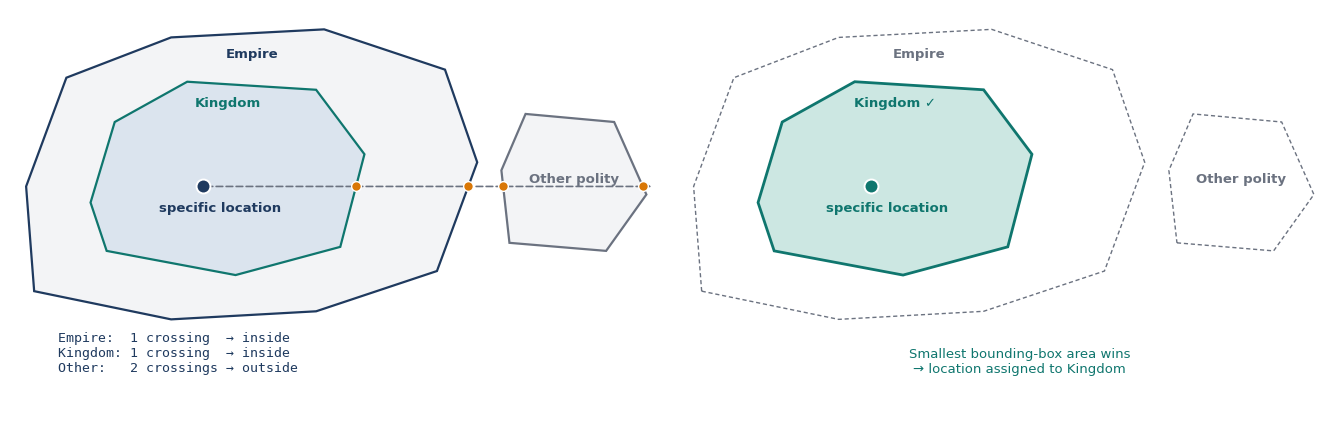

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# ---- Panel 1: ray-cast against each candidate ----
ax = axes[0]
draw_polygon(ax, EMPIRE, LIGHT_GREY, NAVY, 'Empire', (5.0, 6.2), NAVY)
draw_polygon(ax, KINGDOM, LIGHT_BLUE, TEAL, 'Kingdom', (4.4, 5.0), TEAL)
draw_polygon(ax, NEIGHBOR, LIGHT_GREY, GREY, 'Other polity', (13.0, 3.1), GREY)

draw_ray(ax, CITY, (RAY_X_MAX - 0.2, CITY[1]))

emp_x = edge_crossings(CITY, EMPIRE, RAY_X_MAX)
kng_x = edge_crossings(CITY, KINGDOM, RAY_X_MAX)
nei_x = edge_crossings(CITY, NEIGHBOR, RAY_X_MAX)
draw_crossings(ax, emp_x + kng_x + nei_x)

draw_city(ax, CITY)

ax.text(0.2, -0.6,
        f'Empire:  {len(emp_x)} {_plural(len(emp_x))} → inside\n'
        f'Kingdom: {len(kng_x)} {_plural(len(kng_x))} → inside\n'
        f'Other:   {len(nei_x)} {_plural(len(nei_x))} → outside',
        fontsize=9.5, color=NAVY, family='monospace',
        verticalalignment='top')

ax.set_xlim(-1.0, RAY_X_MAX)
ax.set_ylim(-2.6, 7.4)
ax.set_aspect('equal')
ax.axis('off')

# ---- Panel 2: pick smallest matching polygon ----
ax = axes[1]
draw_polygon(ax, EMPIRE, 'white', GREY, 'Empire', (5.0, 6.2), GREY,
             lw=1.0, ls=(0, (3, 2)))
draw_polygon(ax, KINGDOM, LIGHT_TEAL, TEAL, 'Kingdom ✓', (4.4, 5.0), TEAL, lw=2.0)
draw_polygon(ax, NEIGHBOR, 'white', GREY, 'Other polity', (13.0, 3.1), GREY,
             lw=1.0, ls=(0, (3, 2)))
draw_city(ax, CITY, color=TEAL)

ax.text(7.5, -1.6,
        'Smallest bounding-box area wins\n→ location assigned to Kingdom',
        fontsize=9.5, color=TEAL, ha='center')

ax.set_xlim(-1.0, RAY_X_MAX)
ax.set_ylim(-2.6, 7.4)
ax.set_aspect('equal')
ax.axis('off')

fig.tight_layout()
fig.savefig(OUT, bbox_inches='tight')
fig.savefig(OUT.with_suffix('.png'), dpi=300, bbox_inches='tight')
print(f'saved {OUT} and {OUT.with_suffix(".png")}')
plt.show()